# 异质突触位置、参数与 NetStim Contact

这个 notebook 使用真实的 soma + 两条 dendrite 多室 HH cell，完整展示两条入口：

1. 继续使用原来的 `cell[i].place(...)`，显式给不同 population member 放置不同突触；
2. 从 `cell.cv_midpoints` 生成二维 `LocsetBatch`，一次把每一行位置和一个 population member 对齐，再用独立的 `NetStim` 与 `Contact` 建立事件连接。

同一位置、同一机制声明的多次 placement 都是独立实例，不会合并。`NetStim` 只产生事件，weight 与 delay 属于 `Contact`。

In [1]:
from itertools import combinations
import json
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

## 1. 真实 cell 模板

每个 cell 有 5 个 CV：soma 一个，两条 dendrite 各两个。全树放置 sodium、potassium 与 leak channel，并使用正常的 `staggered` solver。CV 在初始化前已经可查询，因此位置组合仍然使用连续的 `(branch_id, branch_x)` 表达。

In [2]:
def build_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma"
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[120.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite"
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um, radii=[2.5, 0.8] * u.um, type="basal_dendrite"
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_population(size):
    cell = braincell.Cell(
        build_morphology(),
        cv_policy=braincell.CVPerBranchList([1, 2, 2]),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        solver="staggered",
    )
    cell.paint(
        AllRegion(),
        braincell.mech.Ion("SodiumFixed", E=50.0 * u.mV),
        braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        braincell.mech.Channel("Na_HH1952", name="na", g_max=120.0 * u.mS / u.cm**2),
        braincell.mech.Channel("K_HH1952", name="k", g_max=36.0 * u.mS / u.cm**2),
        braincell.mech.Channel("IL", name="leak", g_max=0.3 * u.mS / u.cm**2, E=-54.387 * u.mV),
    )
    cell.place(at("soma", 0.5), braincell.mech.StateProbe(name="v", field="v"))
    return cell

,cv_id,branch_id,branch_x
0,0,0,0.50
1,1,1,0.25
2,2,1,0.75
3,3,2,0.25
4,4,2,0.75


<Axes: >

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


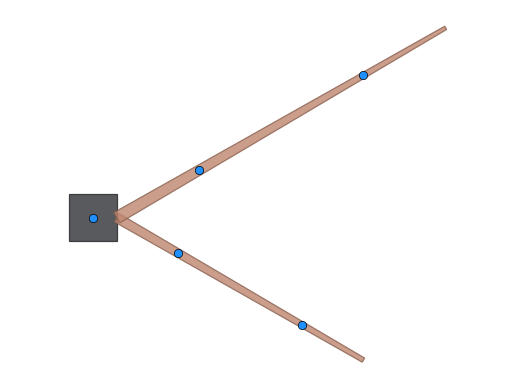

In [3]:
preview = build_population(1)
midpoint_table = pd.DataFrame({
    "cv_id": np.arange(preview.n_cv),
    "branch_id": preview.cv_midpoints.branch_id,
    "branch_x": preview.cv_midpoints.branch_x,
})
display(midpoint_table)
braincell.vis.plot2d(
    preview.morpho, locset=preview.cv_midpoints, backend="matplotlib", notebook=True
)

## 2. 原有 `place` 的显式异质入口

population 切片只决定 placement 属于哪个 cell；位置仍然是普通 LocsetExpr。同一个 `exp` 声明可以重复使用，每次 placement 都得到独立 `placement_id`。

In [4]:
explicit = build_population(4)
explicit_exp = braincell.mech.SynapseSpec("ExpSyn", name="explicit_exp", tau=2.0 * u.ms, e=0.0 * u.mV)
explicit[0].place(at("dend_a", 0.25), explicit_exp)
explicit[1].place(at("dend_a", 0.25) + at("dend_b", 0.75), explicit_exp)
explicit[2].place(at("soma", 0.5), explicit_exp)
explicit[3].place(at("dend_b", 0.25) + at("dend_b", 0.25), explicit_exp)

explicit_view = explicit.synapses[explicit_exp]
explicit_view.set(
    tau=np.arange(1.0, len(explicit_view) + 1.0) * u.ms,
    e=np.linspace(-70.0, 0.0, len(explicit_view)) * u.mV,
)
pd.DataFrame({
    "instance_id": explicit_view.id,
    "placement_id": explicit_view.placement_id,
    "cell_index": explicit_view.population_index,
    "point_id": explicit_view.point_id,
})

,instance_id,placement_id,cell_index,point_id
0,4,1,0,3
1,9,2,1,3
2,13,3,1,7
3,18,4,2,1
4,23,5,3,6
5,27,6,3,6


最后两个 placement 的 branch_x 完全相同，但列表中仍保留两行、两个 placement ID。电气上它们可以共享 point_id，机制状态与 Connection synapse 仍然独立。

## 3. `cv_midpoints[pairs]` 生成 LocsetBatch

5 个 CV 有 `C(5, 2)=10` 个无序 pair。建立一个 size=10 的 population；二维索引结果 shape 为 `(10, 2)`，`place` 把第 i 行的两个位置只交给第 i 个 cell。

In [5]:
pair_indices = np.asarray(list(combinations(range(preview.n_cv), 2)), dtype=np.int32)
pair_cell = build_population(len(pair_indices))
pair_locations = pair_cell.cv_midpoints[pair_indices]
pair_exp = braincell.mech.SynapseSpec("ExpSyn", name="pair_exp", tau=2.0 * u.ms, e=0.0 * u.mV)
pair_cell.place(pair_locations, pair_exp)
pair_targets = pair_cell.synapses[pair_exp]
pair_tau_ms = np.linspace(1.0, 4.0, len(pair_targets))
pair_e_mv = np.linspace(-20.0, 10.0, len(pair_targets))
pair_targets.set(
    tau=pair_tau_ms * u.ms,
    e=pair_e_mv * u.mV,
)

print("pair_locations.shape =", pair_locations.shape)
print("population size =", pair_cell.pop_size[0])
print("synapse instances =", len(pair_targets))
assert pair_locations.shape == (10, 2)
assert len(pair_targets) == 20

pair_locations.shape = (10, 2)
population size = 10
synapse instances = 20


In [6]:
placement_rows = pd.DataFrame({
    "instance_id": pair_targets.id,
    "cell_index": pair_targets.population_index,
    "placement_id": pair_targets.placement_id,
    "cv_id": [item.cv_id for item in pair_targets.instances],
    "branch_id": [item.branch_id for item in pair_targets.instances],
    "branch_x": [item.branch_x for item in pair_targets.instances],
})
display(placement_rows)
display(placement_rows.groupby("cell_index").size().rename("synapse_count"))

,instance_id,cell_index,placement_id,cv_id,branch_id,branch_x
0,10,0,1,0,0,0.50
1,20,0,2,1,1,0.25
2,31,1,3,0,0,0.50
3,41,1,4,2,1,0.75
4,52,2,5,0,0,0.50
5,62,2,6,3,2,0.25
6,73,3,7,0,0,0.50
7,83,3,8,4,2,0.75
8,94,4,9,1,1,0.25
9,104,4,10,2,1,0.75


cell_index
0    2
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: synapse_count, dtype: int64

## 4. 独立 NetStim 与命名 Connection

这里创建 20 个 source。start、interval、noise 都可以按 source 异质；Connection 两端等长时默认一一 zip。weight 可为负，但必须符合目标 synapse model 声明的消费量纲；ExpSyn 消费 `uS`。

In [7]:
source_count = len(pair_targets)
sources = braincell.NetStim(
    size=source_count,
    start=(1.0 + 0.05 * (np.arange(source_count) % 5)) * u.ms,
    number=2,
    interval=(3.0 + 0.1 * np.arange(source_count)) * u.ms,
    noise=np.linspace(0.0, 0.5, source_count),
    seed=11,
)
connections = braincell.connect(
    "heterogeneous_netstim",
    source=sources,
    synapse=pair_targets,
    weight=np.linspace(0.015, 0.045, source_count) * u.uS,
    delay=(0.05 * (np.arange(source_count) % 4)) * u.ms,
)
connection_rows = pd.DataFrame({
    "connection_id": connections.id,
    "source_index": connections.source_index,
    "target_instance": pair_targets.id[connections.target_index],
    "target_cell": pair_targets.population_index[connections.target_index],
    "weight_uS": connections.weight.to_decimal(u.uS),
    "delay_ms": connections.delay.to_decimal(u.ms),
})
display(connection_rows)
print("Cell-owned connection rows:", len(pair_cell.connections))

,connection_id,source_index,target_instance,target_cell,weight_uS,delay_ms
0,0,0,10,0,0.015000,0.00
1,1,1,20,0,0.016579,0.05
2,2,2,31,1,0.018158,0.10
3,3,3,41,1,0.019737,0.15
4,4,4,52,2,0.021316,0.00
5,5,5,62,2,0.022895,0.05
6,6,6,73,3,0.024474,0.10
7,7,7,83,3,0.026053,0.15
8,8,8,94,4,0.027632,0.00
9,9,9,104,4,0.029211,0.05


Cell-owned connection rows: 20


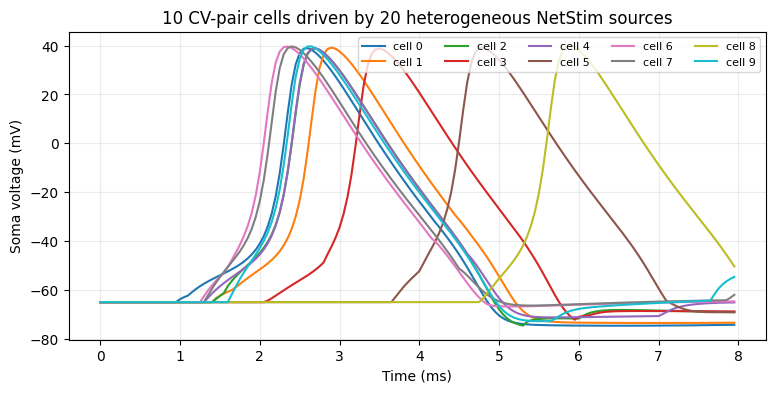

voltage trace shape = (160, 10)


In [13]:
network = braincell.Network(name="netstim_cv_pairs")
network.add_population("post", pair_cell)
network.reset_state()
result = network.run(dt=0.05 * u.ms, duration=8.0 * u.ms)
time_ms = result.time.to_decimal(u.ms)
voltage_mv = np.asarray(result.traces["post"]["v"].to_decimal(u.mV), dtype=float)

fig, ax = plt.subplots(figsize=(9, 4))
for cell_index in range(voltage_mv.shape[1]):
    ax.plot(time_ms, voltage_mv[:, cell_index], label=f"cell {cell_index}")
ax.set(xlabel="Time (ms)", ylabel="Soma voltage (mV)", title="10 CV-pair cells driven by 20 heterogeneous NetStim sources")
ax.grid(alpha=0.25)
ax.legend(ncol=5, fontsize=8)
plt.show()
print("voltage trace shape =", voltage_mv.shape)
assert voltage_mv.shape == (len(time_ms), len(pair_indices))

## 5. Scaling benchmark

benchmark 单独统计 declaration、init、首次编译运行、warm run，以及 source schedule、Connection 列和 synapse runtime buffer 的持久存储。子进程隔离 JAX cache。`broadcast` 与 `heterogeneous` 都是每 cell 两个 synapse，因而主要比较索引/scatter 开销，而不是改变工作量。

In [9]:
script = Path("examples/multi_compartment/netstim_connection_benchmark.py")
if not script.exists():
    script = Path("netstim_connection_benchmark.py")

def run_benchmark(size, mode, *, gpu=False):
    env = os.environ.copy()
    if gpu:
        env["CUDA_VISIBLE_DEVICES"] = "0"
        env["JAX_PLATFORMS"] = "cuda"
    else:
        env["JAX_PLATFORMS"] = "cpu"
    completed = subprocess.run(
        [sys.executable, str(script), "--size", str(size), "--mode", mode, "--steps", "3", "--repeats", "2"],
        check=True, capture_output=True, text=True, env=env,
    )
    return json.loads(completed.stdout.strip().splitlines()[-1])

cpu_rows = [
    run_benchmark(4, "broadcast"),
    run_benchmark(4, "heterogeneous"),
    run_benchmark(16, "heterogeneous"),
]
pd.DataFrame(cpu_rows)

,platform,mode,population_size,synapse_instances,connections,declaration_s,init_s,first_run_s,warm_run_ms,source_bytes,connection_bytes,synapse_bytes,total_bytes
0,cpu,broadcast,4,8,8,0.507750,0.816800,1.203401,315.540153,72,320,128,520
1,cpu,heterogeneous,4,8,8,0.491847,0.860464,1.230442,334.625541,72,320,128,520
2,cpu,heterogeneous,16,32,32,0.589672,0.950534,1.265662,330.134030,288,1280,512,2080


In [10]:
RUN_GPU = False
gpu_rows = [run_benchmark(size, "heterogeneous", gpu=True) for size in (64, 256)] if RUN_GPU else []
pd.DataFrame(gpu_rows)

""


## 结果解释

- `LocsetBatch` 只改变声明/索引方式；runtime 仍是连续的 packed 行，不按最大异质突触数 padding。
- 当每个 cell 都有两个 synapse 时，broadcast 与 packed 的状态元素数量同阶；异质模式额外保存 placement/population/contact 索引。
- 首次运行通常由 JAX 编译主导，warm run 才反映持续运行成本。小规模 GPU 容易被编译和 launch 开销支配，因此 GPU cell 默认不执行。
- `ConnectionView.remove()` 会删除声明，但 connection ID 的空洞不会复用；Cell 统一持有 Connection 行，不依赖 Python 局部变量生命周期。

## 6. 与 NEURON 重放同一份 NetStim 事件

两边使用同一个整数 seed 并不能产生相同的 noisy 事件流：BrainCell 的随机后端与 NEURON Random123 不同。这里由 BrainCell 生成连续事件时间，再用 NEURON 的单事件 `NetStim(number=1, noise=0)` 逐个重放，因此比较不包含随机数差异。回放保留原始 source event time 和每条 connection 的原始 delay，不预先把时间量化到网格。

BrainCell 与 NEURON fixed-step 都把 arrival time（`source event time + delay`）分配到最近的 `dt` 边界；恰好半步时进入较晚边界。下面的事件表同时展示连续 arrival 和实际对应的 nearest grid。注意 `NetCon.record()` 记录的是 source event time，而不是加入 delay 后的 delivery time。

NEURON 仍使用相同的三分支 taper morphology、`nseg=[1, 2, 2]`、HH channel、20 个异质 `ExpSyn`、connection weight 和 delay。NEURON 内置 `hh` 的基础速率以 6.3 C 为参考；设置 `h.celsius = 6.3` 才与这里 BrainCell HH1952 的未缩放基础速率数值一致。

--No graphics will be displayed.


,connection_id,source_index,event_index,source_time_ms,delay_ms,arrival_time_ms,nearest_grid_ms
0,0,0,0,1.000000,0.00,1.000000,1.00
1,0,0,1,4.000000,0.00,4.000000,4.00
2,1,1,0,1.124122,0.05,1.174122,1.15
3,1,1,1,4.191233,0.05,4.241233,4.25
4,2,2,0,1.352987,0.10,1.452987,1.45
5,2,2,1,4.390666,0.10,4.490666,4.50
6,3,3,0,1.548163,0.15,1.698163,1.70
7,3,3,1,4.598790,0.15,4.748790,4.75
8,4,4,0,1.616076,0.00,1.616076,1.60
9,4,4,1,5.326192,0.00,5.326192,5.35


realized BrainCell events = 40
replayed NEURON single-event NetStims = 40
BrainCell voltage shape = (160, 10)
NEURON full/cropped voltage shapes = (161, 10) (160, 10)


,mae_mV,rmse_mV,max_abs_mV
0,1.700000e-08,3.300000e-08,2.790000e-07


,cell_index,mae_mV,rmse_mV,max_abs_mV
0,0,2.800000e-08,5.400000e-08,2.790000e-07
1,1,2.200000e-08,4.200000e-08,2.190000e-07
2,2,1.900000e-08,3.300000e-08,1.700000e-07
3,3,1.200000e-08,2.300000e-08,1.200000e-07
4,4,2.300000e-08,4.100000e-08,2.080000e-07
5,5,1.200000e-08,2.400000e-08,1.230000e-07
6,6,9.000000e-09,1.700000e-08,8.800000e-08
7,7,1.700000e-08,2.800000e-08,1.470000e-07
8,8,1.300000e-08,2.700000e-08,1.430000e-07
9,9,1.300000e-08,2.500000e-08,1.300000e-07


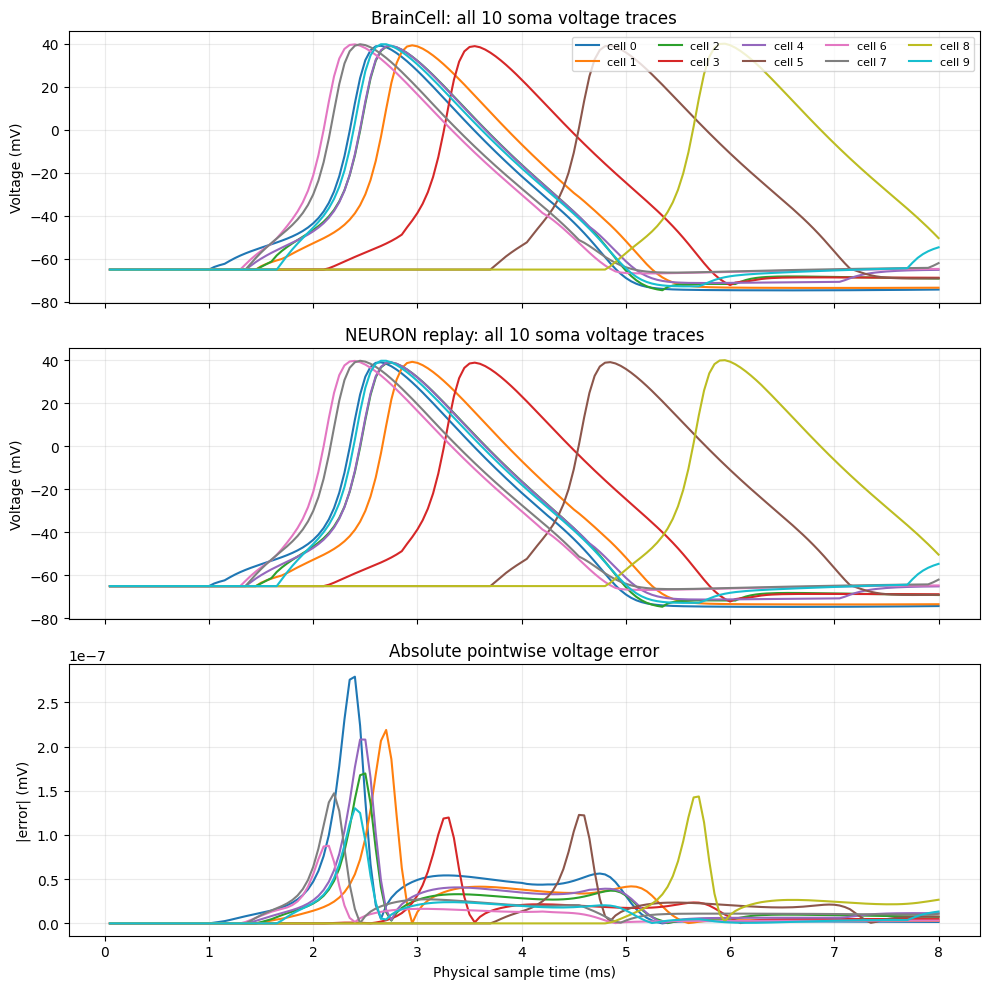

In [11]:
from neuron import h

DT_MS = 0.05
DURATION_MS = 8.0
braincell_voltage_mv = np.asarray(result.traces["post"]["v"].to_decimal(u.mV), dtype=float)
braincell_event_times_ms = np.asarray(sources.event_times.to_decimal(u.ms), dtype=float)

event_rows = []
for connection_row in range(len(connections)):
    source_index = int(connections.source_index[connection_row])
    delay_ms = float(connections.delay[connection_row].to_decimal(u.ms))
    for event_index in range(int(sources.number[source_index])):
        source_time_ms = float(braincell_event_times_ms[source_index, event_index])
        arrival_time_ms = source_time_ms + delay_ms
        nearest_grid_ms = np.floor(arrival_time_ms / DT_MS + 0.5) * DT_MS
        event_rows.append({
            "connection_id": int(connections.id[connection_row]),
            "source_index": source_index,
            "event_index": event_index,
            "source_time_ms": source_time_ms,
            "delay_ms": delay_ms,
            "arrival_time_ms": arrival_time_ms,
            "nearest_grid_ms": nearest_grid_ms,
        })
display(pd.DataFrame(event_rows).head(10))
print("realized BrainCell events =", len(event_rows))

def make_neuron_section(name, *, length_um, proximal_diameter_um, distal_diameter_um, nseg):
    section = h.Section(name=name)
    section.nseg = nseg
    section.Ra = 100.0
    section.cm = 1.0
    h.pt3dclear(sec=section)
    h.pt3dadd(0.0, 0.0, 0.0, proximal_diameter_um, sec=section)
    h.pt3dadd(length_um, 0.0, 0.0, distal_diameter_um, sec=section)
    section.insert("hh")
    section.ena = 50.0
    section.ek = -77.0
    for segment in section:
        segment.hh.gnabar = 0.120
        segment.hh.gkbar = 0.036
        segment.hh.gl = 0.0003
        segment.hh.el = -54.387
    return section

def run_neuron_replay():
    h.load_file("stdrun.hoc")
    previous_celsius = float(h.celsius)
    h.celsius = 6.3
    cells = []
    sections = []
    synapses = []
    replay_stims = []
    replay_netcons = []
    source_event_records = []
    expected_source_times = []
    voltage_vectors = []

    try:
        for cell_index in range(len(pair_indices)):
            soma = make_neuron_section(
                f"compare_soma_{cell_index}", length_um=20.0,
                proximal_diameter_um=20.0, distal_diameter_um=20.0, nseg=1,
            )
            dend_a = make_neuron_section(
                f"compare_dend_a_{cell_index}", length_um=120.0,
                proximal_diameter_um=4.0, distal_diameter_um=2.0, nseg=2,
            )
            dend_b = make_neuron_section(
                f"compare_dend_b_{cell_index}", length_um=160.0,
                proximal_diameter_um=5.0, distal_diameter_um=1.6, nseg=2,
            )
            dend_a.connect(soma(1.0), 0.0)
            dend_b.connect(soma(1.0), 0.0)
            cell_sections = {0: soma, 1: dend_a, 2: dend_b}
            cells.append(cell_sections)
            sections.extend(cell_sections.values())
            voltage_vectors.append(h.Vector().record(soma(0.5)._ref_v))

        for target_index, instance in enumerate(pair_targets.instances):
            synapse = h.ExpSyn(cells[instance.population_index][instance.branch_id](instance.branch_x))
            synapse.tau = float(pair_tau_ms[target_index])
            synapse.e = float(pair_e_mv[target_index])
            synapses.append(synapse)

        for connection_row in range(len(connections)):
            source_index = int(connections.source_index[connection_row])
            target_index = int(connections.target_index[connection_row])
            event_count = int(sources.number[source_index])
            for event_time_ms in braincell_event_times_ms[source_index, :event_count]:
                stim = h.NetStim()
                stim.start = float(event_time_ms)
                stim.number = 1
                stim.interval = 1.0
                stim.noise = 0.0
                netcon = h.NetCon(stim, synapses[target_index])
                netcon.weight[0] = float(connections.weight[connection_row].to_decimal(u.uS))
                netcon.delay = float(connections.delay[connection_row].to_decimal(u.ms))
                record = h.Vector()
                netcon.record(record)
                replay_stims.append(stim)
                replay_netcons.append(netcon)
                source_event_records.append(record)
                expected_source_times.append(float(event_time_ms))

        time_vector = h.Vector().record(h._ref_t)
        h.cvode_active(0)
        h.dt = DT_MS
        h.steps_per_ms = 1.0 / DT_MS
        h.dt = DT_MS
        h.secondorder = 0
        h.finitialize(-65.0)
        h.tstop = DURATION_MS
        h.run()

        neuron_time_ms = np.asarray(time_vector, dtype=float)
        neuron_voltage_mv = np.column_stack([np.asarray(vector, dtype=float) for vector in voltage_vectors])
        recorded_source_times = [
            float(record[0]) for expected, record in zip(expected_source_times, source_event_records)
            if expected <= DURATION_MS and len(record) == 1
        ]
        expected_source_times_in_run = [time for time in expected_source_times if time <= DURATION_MS]
        np.testing.assert_allclose(recorded_source_times, expected_source_times_in_run, atol=1e-12, rtol=0.0)
        return neuron_time_ms, neuron_voltage_mv, len(replay_stims)
    finally:
        h.celsius = previous_celsius
        for section in sections:
            h.delete_section(sec=section)

neuron_time_full_ms, neuron_voltage_full_mv, replay_count = run_neuron_replay()
neuron_time_ms = neuron_time_full_ms[1:]
neuron_voltage_mv = neuron_voltage_full_mv[1:]
aligned_time_ms = np.asarray(time_ms, dtype=float) + DT_MS

assert braincell_voltage_mv.shape == (160, 10)
assert neuron_voltage_full_mv.shape == (161, 10)
assert neuron_voltage_mv.shape == braincell_voltage_mv.shape
np.testing.assert_allclose(neuron_time_ms, aligned_time_ms, atol=1e-5, rtol=0.0)
print("replayed NEURON single-event NetStims =", replay_count)
print("BrainCell voltage shape =", braincell_voltage_mv.shape)
print("NEURON full/cropped voltage shapes =", neuron_voltage_full_mv.shape, neuron_voltage_mv.shape)

voltage_error_mv = braincell_voltage_mv - neuron_voltage_mv
per_cell_error = pd.DataFrame({
    "cell_index": np.arange(braincell_voltage_mv.shape[1]),
    "mae_mV": np.mean(np.abs(voltage_error_mv), axis=0),
    "rmse_mV": np.sqrt(np.mean(voltage_error_mv**2, axis=0)),
    "max_abs_mV": np.max(np.abs(voltage_error_mv), axis=0),
})
global_error = pd.DataFrame([{
    "mae_mV": np.mean(np.abs(voltage_error_mv)),
    "rmse_mV": np.sqrt(np.mean(voltage_error_mv**2)),
    "max_abs_mV": np.max(np.abs(voltage_error_mv)),
}])
display(global_error.round(9))
display(per_cell_error.round(9))
np.testing.assert_allclose(braincell_voltage_mv, neuron_voltage_mv, atol=1e-5, rtol=0.0)
np.testing.assert_array_equal(
    np.argmax(braincell_voltage_mv, axis=0),
    np.argmax(neuron_voltage_mv, axis=0),
)

colors = plt.cm.tab10(np.arange(10))
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for cell_index, color in enumerate(colors):
    axes[0].plot(aligned_time_ms, braincell_voltage_mv[:, cell_index], color=color, label=f"cell {cell_index}")
    axes[1].plot(neuron_time_ms, neuron_voltage_mv[:, cell_index], color=color)
    axes[2].plot(aligned_time_ms, np.abs(voltage_error_mv[:, cell_index]), color=color)
axes[0].set(title="BrainCell: all 10 soma voltage traces", ylabel="Voltage (mV)")
axes[1].set(title="NEURON replay: all 10 soma voltage traces", ylabel="Voltage (mV)")
axes[2].set(title="Absolute pointwise voltage error", xlabel="Physical sample time (ms)", ylabel="|error| (mV)")
axes[0].legend(ncol=5, fontsize=8)
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### 如何解释误差

在相同 morphology、参数、初始状态、nearest-grid 事件边界和 float64 精度下，两边的曲线应只剩数值舍入级误差。代码用 `1e-5 mV` 的逐点绝对误差和完全相同的 peak sample index 作为回归门槛。`NetCon.record()` 只验证 source event time；真正的 delivery 仍由原始 delay 在 NEURON 内部完成。NEURON 记录天然包含 `t=0` 初始状态，比较前用 `[1:]` 裁掉这一行；BrainCell trace 的标签是步起点，所以绘图时加一个 `dt` 对齐到实际采样时刻。